## QUASI-STATITC SPRING SLIDER

### INTEGRATION

In [21]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.differentiate import jacobian
import matplotlib.pyplot as plt

In [3]:
## CONSTANTS

beta_1 = 1
beta_2 = 0.84
rho = 0.048

kappa_prime = 0.8544
kappa_cr_1 = beta_1 - 1
kappa_cr_2 = (
    kappa_cr_1 + rho*(2*beta_1 + (beta_2-1)*(2+rho)) + np.sqrt(
        4*rho**2 * (kappa_cr_1+beta_2) + (kappa_cr_1 + rho**2 * (beta_2-1))**2
    )
) / (2*(1+rho))

kappa = kappa_cr_2 * kappa_prime

In [28]:
## define EOMS

v_0 = 1

def func(input_vars):
    x, y, z = input_vars

    return (
        (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
            x*(beta_1-1) + y - z
        ) + rho * np.exp(x) * (beta_2*x + z)),
        -kappa * (np.exp(x)-v_0),
        -rho*np.exp(x)*(
            beta_2*x+z
        )
    )

def t_func(t, input_vars):
    
    return func(input_vars)

In [29]:
## solve ivp

t_start = 0
t_end = 4000
dt = 0.1

t_eval = np.arange(t_start, t_end+0.1, dt)

x_0 = (0.05, 0, 0)

soln = solve_ivp(t_func, (t_start, t_end), x_0, t_eval=t_eval)

C:\Users\nookh\AppData\Local\Temp\ipykernel_19848\2316256604.py:9: RuntimeWarning: overflow encountered in exp
  (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
C:\Users\nookh\AppData\Local\Temp\ipykernel_19848\2316256604.py:11: RuntimeWarning: overflow encountered in exp
  ) + rho * np.exp(x) * (beta_2*x + z)),
C:\Users\nookh\AppData\Local\Temp\ipykernel_19848\2316256604.py:9: RuntimeWarning: invalid value encountered in scalar add
  (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
C:\Users\nookh\AppData\Local\Temp\ipykernel_19848\2316256604.py:12: RuntimeWarning: overflow encountered in exp
  -kappa * (np.exp(x)-v_0),
C:\Users\nookh\AppData\Local\Temp\ipykernel_19848\2316256604.py:13: RuntimeWarning: overflow encountered in exp
  -rho*np.exp(x)*(


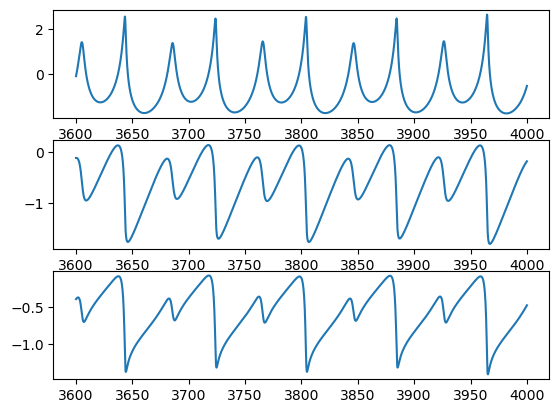

In [19]:
num_pts = 4000

t = soln.t[-num_pts:]
x, y, z = soln.y[:,-num_pts:]

fig, axs = plt.subplots(3, 1)
axs = axs.flatten()

axs[0].plot(t, x)
axs[1].plot(t, y)
axs[2].plot(t, z)

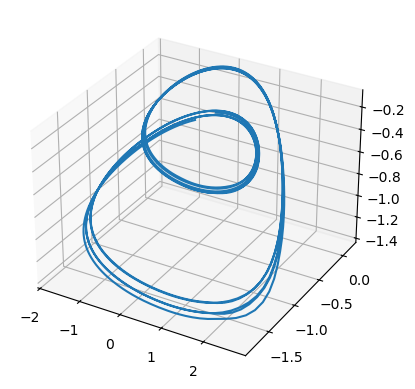

In [20]:
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot(x, y, z)

### LYAPUNOVE SPECTRUM AND KAPLAN-YORKE DIMENSION

In [25]:
t

array([3600.1, 3600.2, 3600.3, ..., 3999.8, 3999.9, 4000. ], shape=(4000,))

In [ ]:
R_diagonals = []

I = np.eye(3)

V_prime = I.copy()

for t_id in range(len(soln.t)):
    jac = jacobian(func, soln.y[:,t_id]).df
    A = I + jac * dt

    V = A @ V_prime

    qr_V = np.linalg.qr(V)

    new_V = qr_V.Q
    new_R = qr_V.R

    R_diag = np.log(np.abs(new_R.diagonal()))

    R_diagonals.append(R_diag / dt)

    V_prime = new_V

R_diagonals = np.array(R_diagonals)


In [78]:
with open('R_diagonals.txt', 'w') as out_file:

    out_file.write(repr(
        list(
            [float(j) for j in i] for i in R_diagonals
        )
    ))

In [83]:
R_diagonals/dt

array([[-0.02727457,  0.00733774, -0.05517614],
       [-0.02985392,  0.0144261 , -0.05983731],
       [-0.03246395,  0.02152301, -0.06447637],
       ...,
       [ 0.05982067,  0.06820195, -0.02287564],
       [ 0.06130167,  0.06706367, -0.02070845],
       [ 0.0628136 ,  0.06588257, -0.01848027]], shape=(40001, 3))

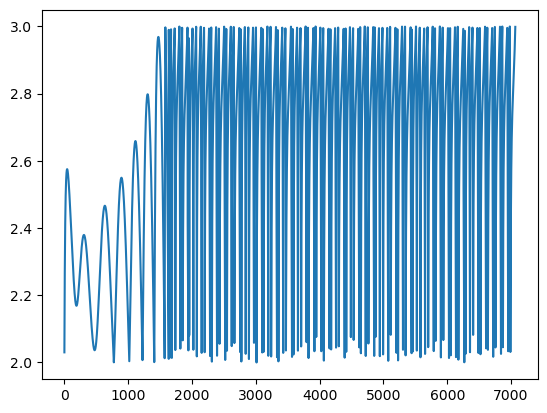

In [88]:
diff_sum_0 = R_diagonals[:, 0] + R_diagonals[:, 1]
diff_sum_1 = R_diagonals[:, 0] + R_diagonals[:, 1] + R_diagonals[:,2]

mask_0 = diff_sum_0 >= 0
mask_1 = diff_sum_1 < 0

ky_mask = mask_0 & mask_1

valid_ky = R_diagonals[ky_mask]

ly_dim = 2 + (valid_ky[:,0]+valid_ky[:,1])/np.abs(valid_ky[:,2])

plt.plot(ly_dim)